# 05 — OSM pedestrian network

Walk network from **`data/raw/osm/sd_walk_network.graphml`** (downloaded via `scripts/download_data.py --sources osm` for the study **bbox** in `configs/san_diego.yaml`).

## Goals
- **Graph scale:** nodes, edges, total edge length (projected meters), weakly connected components.
- **Tract association:** edge **centroids** → census tract (fast proxy for “walk infrastructure density”); edge length summed per tract.
- **Equity spot-check:** Spearman — walk edge density vs `disadvantage_z` (merged from latest `eda__tract_gtfs_service__*.csv` when present).

**Exports:** `artifacts/tables/` + `artifacts/figures/`; index in `context/structure.md`.

**Prior:** [`04_spatial_alignment_and_coverage.ipynb`](04_spatial_alignment_and_coverage.ipynb)  
**Next:** [`06_opportunities_and_destinations.ipynb`](06_opportunities_and_destinations.ipynb)


In [1]:
from __future__ import annotations

import warnings
from datetime import date
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
import yaml
from IPython.display import Markdown, display
from scipy import stats
from shapely.geometry import box

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")


def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "configs" / "san_diego.yaml").exists():
            return d
    raise FileNotFoundError("Could not find configs/san_diego.yaml (cd to repo root).")


REPO_ROOT = find_repo_root()
with open(REPO_ROOT / "configs" / "defaults.yaml") as f:
    config = yaml.safe_load(f)
with open(REPO_ROOT / "configs" / "san_diego.yaml") as f:
    config.update(yaml.safe_load(f))

bbox = config["bbox"]
min_lon, min_lat, max_lon, max_lat = bbox
census_cfg = config.get("census", {})
state_fips = str(census_cfg.get("state_fips", config.get("state_fips", "06"))).zfill(2)
county_fips = str(census_cfg.get("county_fips", config.get("county_fips", "073"))).zfill(3)
acs_year = int(census_cfg.get("acs_year", 2023))

TODAY = date.today().isoformat()
ART_TABLES = REPO_ROOT / "artifacts" / "tables"
ART_FIG = REPO_ROOT / "artifacts" / "figures"
ART_TABLES.mkdir(parents=True, exist_ok=True)
ART_FIG.mkdir(parents=True, exist_ok=True)

PROJ_CRS = "EPSG:3310"
GRAPHML = REPO_ROOT / "data" / "raw" / "osm" / "sd_walk_network.graphml"

print(f"REPO_ROOT={REPO_ROOT}")
print(f"GRAPHML exists={GRAPHML.is_file()}  bbox={bbox}")


REPO_ROOT=C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity
GRAPHML exists=True  bbox=[-117.4, 32.53, -116.8, 33.35]


## Load graph and project to meters (California Albers)


In [2]:
if not GRAPHML.is_file():
    raise FileNotFoundError(
        f"Missing {GRAPHML}. Run: python scripts/download_data.py --config configs/san_diego.yaml --sources osm"
    )

G = ox.load_graphml(GRAPHML)
print(f"Loaded graph: {len(G):,} nodes, {len(G.edges):,} edges (directed)")

G = ox.project_graph(G, to_crs=PROJ_CRS)
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
print(f"GeoDataFrames: nodes {len(nodes_gdf):,}  edges {len(edges_gdf):,}  CRS={edges_gdf.crs}")


Loaded graph: 337,824 nodes, 906,988 edges (directed)
GeoDataFrames: nodes 337,824  edges 906,988  CRS=EPSG:3310


## Graph-level summary


In [3]:
length_m = edges_gdf["length"].astype(float) if "length" in edges_gdf.columns else edges_gdf.geometry.length
length_m = pd.to_numeric(length_m, errors="coerce").fillna(0)
total_km = float(length_m.sum() / 1000.0)

comps = list(nx.weakly_connected_components(G))
comp_sizes = sorted((len(c) for c in comps), reverse=True)
n_comp = len(comp_sizes)

summary = pd.DataFrame(
    [
        {"metric": "n_nodes", "value": len(G)},
        {"metric": "n_edges_directed", "value": len(G.edges)},
        {"metric": "n_edge_rows_gdf", "value": len(edges_gdf)},
        {"metric": "total_edge_length_km", "value": round(total_km, 3)},
        {"metric": "mean_edge_length_m", "value": round(float(length_m.mean()), 2)},
        {"metric": "n_weakly_connected_components", "value": n_comp},
        {"metric": "largest_component_n_nodes", "value": comp_sizes[0]},
        {"metric": "second_largest_component_n_nodes", "value": comp_sizes[1] if n_comp > 1 else ""},
    ]
)

display(Markdown("### Walk network summary"))
display(summary)

top_comp = pd.DataFrame({"rank": range(1, min(11, n_comp) + 1), "component_size_nodes": comp_sizes[:10]})
display(Markdown("### Ten largest weakly connected components (node count)"))
display(top_comp)

p_sum = ART_TABLES / f"eda__osm_walk_graph_summary__{TODAY}.csv"
summary.to_csv(p_sum, index=False)
print(f"Saved: {p_sum.relative_to(REPO_ROOT)}")

p_comp = ART_TABLES / f"eda__osm_walk_component_sizes__{TODAY}.csv"
pd.DataFrame({"component_size_nodes": comp_sizes}).to_csv(p_comp, index=False)
print(f"Saved: {p_comp.relative_to(REPO_ROOT)}")


### Walk network summary

,metric,value
0,n_nodes,337824
1,n_edges_directed,906988
2,n_edge_rows_gdf,906988
3,total_edge_length_km,65749.995
4,mean_edge_length_m,72.49
5,n_weakly_connected_components,1
6,largest_component_n_nodes,337824
7,second_largest_component_n_nodes,


### Ten largest weakly connected components (node count)

,rank,component_size_nodes
0,1,337824


Saved: artifacts\tables\eda__osm_walk_graph_summary__2026-03-30.csv
Saved: artifacts\tables\eda__osm_walk_component_sizes__2026-03-30.csv


## TIGER tracts (San Diego County) + study bbox


In [4]:
tiger_dir = REPO_ROOT / "data" / "raw" / "census" / f"tl_{acs_year}_{state_fips}_tract"
shp = tiger_dir / f"tl_{acs_year}_{state_fips}_tract.shp"
if not shp.exists():
    raise FileNotFoundError(f"Missing TIGER shapefile: {shp}")

tracts_all = gpd.read_file(shp)
tracts_sd = tracts_all[
    (tracts_all["STATEFP"].astype(str).str.zfill(2) == state_fips)
    & (tracts_all["COUNTYFP"].astype(str).str.zfill(3) == county_fips)
].copy()
tracts_sd["GEOID"] = tracts_sd["GEOID"].astype(str)

study_poly = box(min_lon, min_lat, max_lon, max_lat)
tracts_sd["intersects_study_bbox"] = tracts_sd.geometry.intersects(study_poly)
tracts_sd_proj = tracts_sd.to_crs(PROJ_CRS)
tracts_sd["area_km2"] = tracts_sd_proj.geometry.area / 1e6

bbox_gdf = gpd.GeoDataFrame(geometry=[study_poly], crs="EPSG:4326")
print(f"SD county tracts: {len(tracts_sd)}  intersect study bbox: {tracts_sd['intersects_study_bbox'].sum()}")


SD county tracts: 737  intersect study bbox: 726


## Edge centroids → tract (length summed per tract)

Centroid-in-tract is a **deliberate EDA approximation** (faster than full line–polygon intersection on ~650k edges).


In [5]:
cent = edges_gdf[["geometry"]].copy()
cent["length_m"] = length_m  # aligned on same MultiIndex as edges_gdf
cent["geometry"] = cent.geometry.centroid
cent = cent[["length_m", "geometry"]]

tract_geoms = tracts_sd_proj[["GEOID", "geometry"]].copy()
sj = gpd.sjoin(cent, tract_geoms, how="left", predicate="within")
miss = sj["GEOID"].isna().sum()
if miss:
    display(Markdown(f"_Note: {miss:,} edge centroids outside SD county tract polygons (expected near bbox edges / coast)._"))

agg = (
    sj.dropna(subset=["GEOID"])
    .groupby("GEOID", as_index=False)
    .agg(n_osm_walk_edges=("length_m", "count"), walk_edge_length_m=("length_m", "sum"))
)

base = tracts_sd[["GEOID", "NAME", "intersects_study_bbox", "area_km2"]].drop_duplicates("GEOID")
tract_walk = base.merge(agg, on="GEOID", how="left")
tract_walk["n_osm_walk_edges"] = tract_walk["n_osm_walk_edges"].fillna(0).astype(int)
tract_walk["walk_edge_length_m"] = tract_walk["walk_edge_length_m"].fillna(0.0)
tract_walk["walk_edge_length_km"] = tract_walk["walk_edge_length_m"] / 1000.0
tract_walk["walk_edge_density_km_per_km2"] = np.where(
    tract_walk["area_km2"] > 0,
    tract_walk["walk_edge_length_km"] / tract_walk["area_km2"],
    np.nan,
)

svc_glob = sorted(ART_TABLES.glob("eda__tract_gtfs_service__*.csv"))
if svc_glob:
    svc = pd.read_csv(svc_glob[-1], dtype={"GEOID": str})
    keep = [c for c in ("GEOID", "disadvantage_z", "poverty_rate", "n_stops_in_bbox") if c in svc.columns]
    tract_walk = tract_walk.merge(svc[keep], on="GEOID", how="left", suffixes=("", "_svc"))
    print(f"Merged tract service columns from {svc_glob[-1].name}")
else:
    print("No eda__tract_gtfs_service__*.csv — run notebook 04 for merge columns.")

tract_walk = tract_walk.sort_values("GEOID").reset_index(drop=True)

p_tw = ART_TABLES / f"eda__osm_tract_walk_edges__{TODAY}.csv"
tract_walk.to_csv(p_tw, index=False)
print(f"Saved: {p_tw.relative_to(REPO_ROOT)}  (n={len(tract_walk)})")

if "disadvantage_z" in tract_walk.columns:
    sub = tract_walk.dropna(subset=["walk_edge_density_km_per_km2", "disadvantage_z"])
    sub = sub[np.isfinite(sub["walk_edge_density_km_per_km2"]) & np.isfinite(sub["disadvantage_z"])]
    if len(sub) > 10:
        rho, pval = stats.spearmanr(sub["walk_edge_density_km_per_km2"], sub["disadvantage_z"])
        display(
            Markdown(
                f"### Spearman: walk edge density (km/km²) vs `disadvantage_z` — "
                f"ρ = {rho:.3f}, p = {pval:.3g} (n = {len(sub)})"
            )
        )
        corr_row = pd.DataFrame(
            [
                {
                    "comparison": "walk_edge_density_km_per_km2 vs disadvantage_z",
                    "n": len(sub),
                    "spearman_rho": rho,
                    "p_value": pval,
                }
            ]
        )
        p_corr = ART_TABLES / f"eda__osm_walk_disadvantage_spearman__{TODAY}.csv"
        corr_row.to_csv(p_corr, index=False)
        print(f"Saved: {p_corr.relative_to(REPO_ROOT)}")


_Note: 25,706 edge centroids outside SD county tract polygons (expected near bbox edges / coast)._

Merged tract service columns from eda__tract_gtfs_service__2026-03-30.csv
Saved: artifacts\tables\eda__osm_tract_walk_edges__2026-03-30.csv  (n=737)


### Spearman: walk edge density (km/km²) vs `disadvantage_z` — ρ = 0.371, p = 1.68e-25 (n = 737)

Saved: artifacts\tables\eda__osm_walk_disadvantage_spearman__2026-03-30.csv


## Figures


Saved: artifacts\figures\eda__osm_tract_walk_density_choropleth__2026-03-30.png


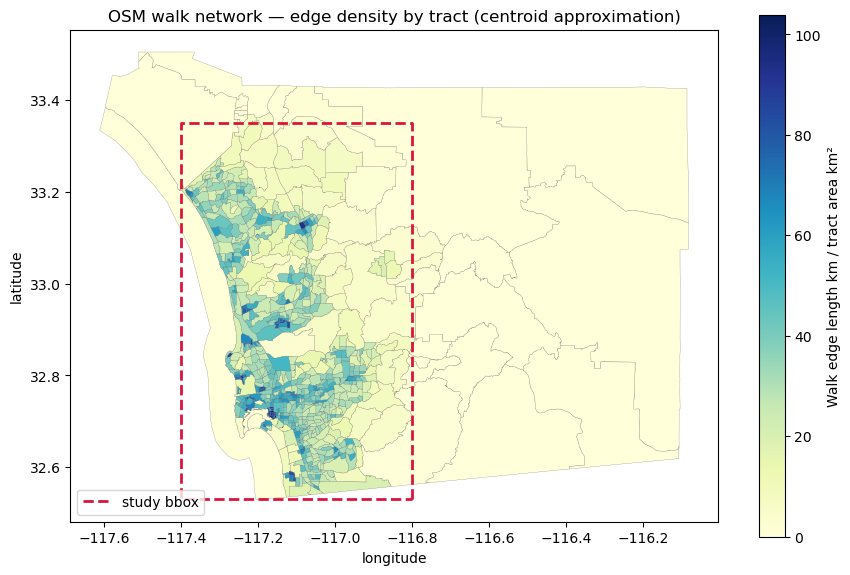

Saved: artifacts\figures\eda__osm_walk_network_sample_map__2026-03-30.png


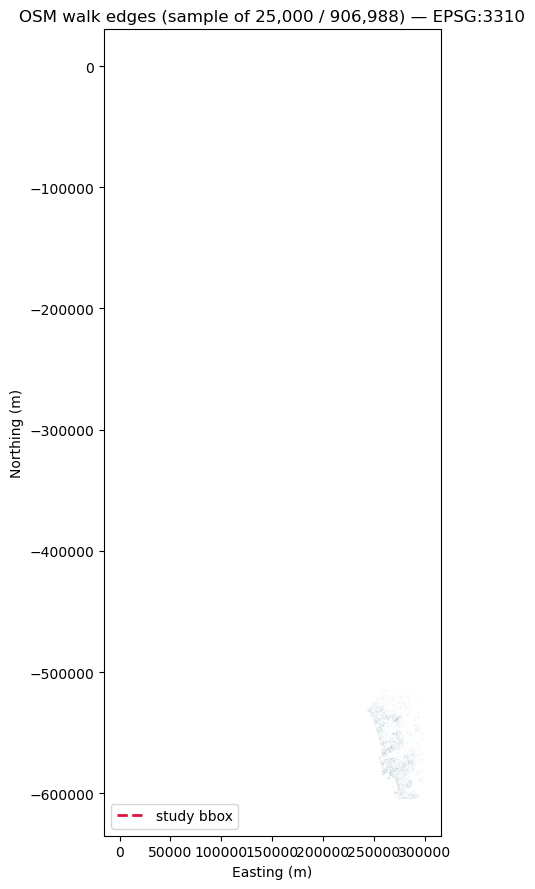

In [6]:
plot_tracts = tracts_sd.merge(
    tract_walk[["GEOID", "walk_edge_density_km_per_km2"]], on="GEOID", how="left"
)

fig, ax = plt.subplots(figsize=(9, 9))
plot_tracts.plot(
    column="walk_edge_density_km_per_km2",
    ax=ax,
    legend=True,
    cmap="YlGnBu",
    edgecolor="0.35",
    linewidth=0.15,
    legend_kwds={"label": "Walk edge length km / tract area km²", "shrink": 0.6},
    missing_kwds={"color": "whitesmoke"},
)
bbox_gdf.boundary.plot(ax=ax, color="crimson", linewidth=2, linestyle="--", label="study bbox")
ax.set_title("OSM walk network — edge density by tract (centroid approximation)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.legend(loc="lower left")
plt.tight_layout()
fp1 = ART_FIG / f"eda__osm_tract_walk_density_choropleth__{TODAY}.png"
fig.savefig(fp1, dpi=200, bbox_inches="tight")
print(f"Saved: {fp1.relative_to(REPO_ROOT)}")
plt.show()

max_edges_plot = 25_000
edges_sub = edges_gdf if len(edges_gdf) <= max_edges_plot else edges_gdf.sample(max_edges_plot, random_state=42)
fig2, ax2 = plt.subplots(figsize=(9, 9))
edges_sub.plot(ax=ax2, color="steelblue", linewidth=0.15, alpha=0.45)
bbox_gdf.boundary.plot(ax=ax2, color="crimson", linewidth=2, linestyle="--", label="study bbox")
ax2.set_title(f"OSM walk edges (sample of {len(edges_sub):,} / {len(edges_gdf):,}) — {PROJ_CRS}")
ax2.set_xlabel("Easting (m)")
ax2.set_ylabel("Northing (m)")
ax2.legend(loc="lower left")
plt.tight_layout()
fp2 = ART_FIG / f"eda__osm_walk_network_sample_map__{TODAY}.png"
fig2.savefig(fp2, dpi=200, bbox_inches="tight")
print(f"Saved: {fp2.relative_to(REPO_ROOT)}")
plt.show()
